In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [8]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
df = df[['v1', 'v2']]

In [10]:
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()

In [12]:
# LABEL SMOOTHING
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

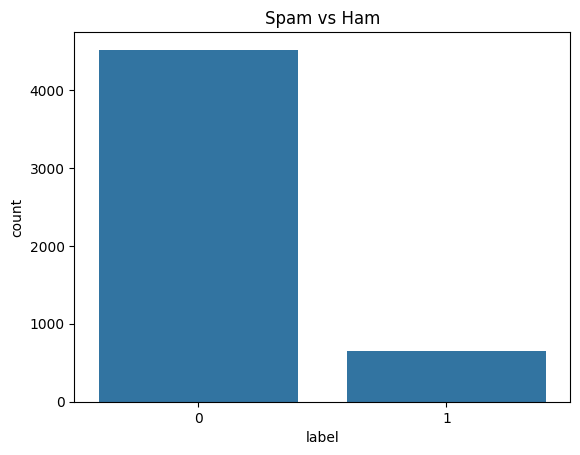

In [13]:
# Exploratory Data Analysis
#Count plot

sns.countplot(x='label', data=df)
plt.title("Spam vs Ham")
plt.show()

In [14]:
# Message length

df['length'] = df['message'].apply(len)

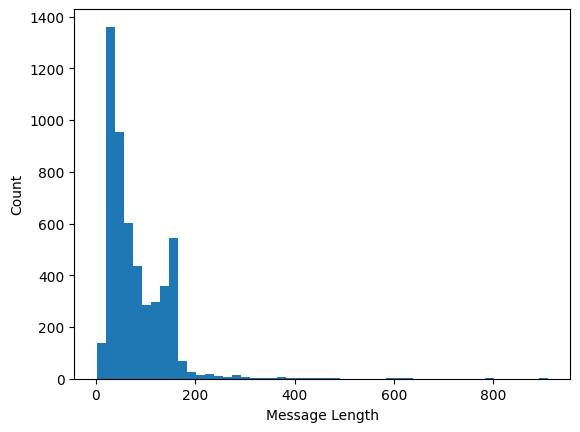

In [15]:
# Histogram

plt.hist(df['length'], bins=50)
plt.xlabel("Message Length")
plt.ylabel("Count")
plt.show()

In [16]:
# Text Cleaning
nltk.download('stopwords')
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))
def clean_text(text):

    text = text.lower()
    text = ''.join(
        char for char in text
        if char not in string.punctuation
    )
    words = text.split()
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amolk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
df['clean_message'] = df['message'].apply(clean_text)

In [18]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_message'])
y = df['label']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Model 1 Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

In [21]:
# MODEL 2 LOGISTIC REGRESSION
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [22]:
# MODEL 3 SVM
svm = LinearSVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [24]:
# EVALUATION FUNCTION
def evaluate_model(name, y_test, y_pred):
    print("="*50)
    print(name)
    print("="*50)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print()
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Naive Bayes
Accuracy : 0.9748549323017408

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       1.00      0.82      0.90       145

    accuracy                           0.97      1034
   macro avg       0.99      0.91      0.94      1034
weighted avg       0.98      0.97      0.97      1034



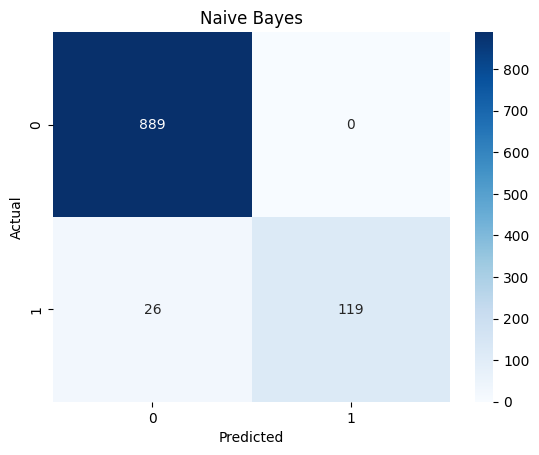

Logistic Regression
Accuracy : 0.9564796905222437

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       889
           1       0.95      0.73      0.82       145

    accuracy                           0.96      1034
   macro avg       0.95      0.86      0.90      1034
weighted avg       0.96      0.96      0.95      1034



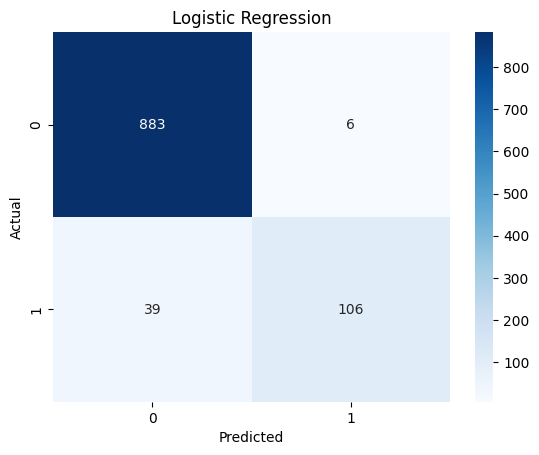

Linear SVM
Accuracy : 0.9806576402321083

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889
           1       0.98      0.88      0.93       145

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



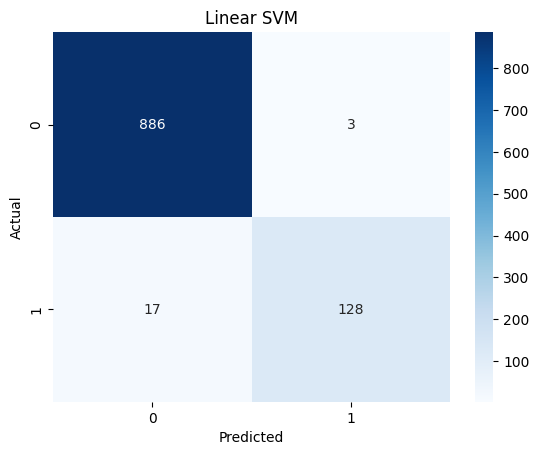

In [25]:
evaluate_model("Naive Bayes", y_test, nb_pred)
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Linear SVM", y_test, svm_pred)

In [26]:
# Compare Accuracy
models = ["Naive Bayes",
          "Logistic Regression",
          "Linear SVM"]

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]

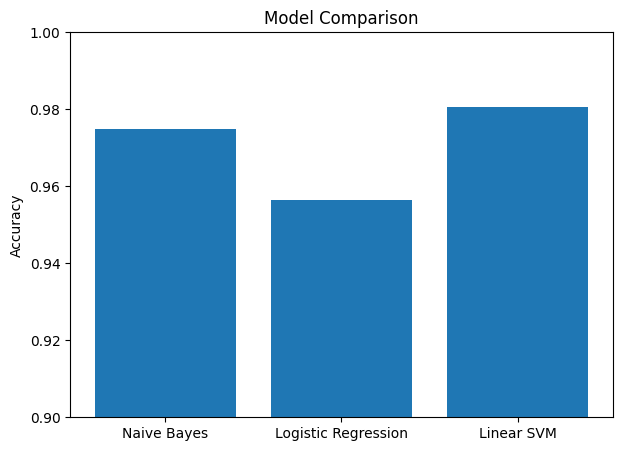

In [27]:
plt.figure(figsize=(7,5))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0.9,1)
plt.show()

In [28]:
import joblib
joblib.dump(svm, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [29]:
# Custom Prediction
def predict_sms(message):

    cleaned = clean_text(message)
    vector = tfidf.transform([cleaned])
    prediction = svm.predict(vector)[0]
    if prediction == 1:
        return "Spam"
    return "Ham"

In [30]:
predict_sms("Congratulations! You won ₹50,000. Click here to claim.")

'Spam'